# Dataset Composition

This notebook examines the composition of the Twin-2K-500 `wave_split` configuration. 

This includes:
1. The questions and behavioral domains represented in participant
   personas
2. Participant demographic distributions
3. Question and response formats
4. Participant coverage across question IDs
5. The composition of the wave 4 evaluation questions
6. Dataset biases and limitations


In [1]:
%load_ext jupyter_black

In [2]:
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from datasets import Value, load_dataset
from huggingface_hub import hf_hub_download

## Load Dataset

In [3]:
DATASET_ID = "LLM-Digital-Twin/Twin-2K-500"

In [4]:
wave_split = load_dataset(DATASET_ID, "wave_split", split="data").cast_column(
    "pid", Value("string")
)

## Persona Composition

Each participant's persona is constructed based on their responses in waves 1-3.

The persona consists of four key categories:
1. **Cognitive tests**: Questions that test participants’ reasoning, logic, and how well they think they performed.
2. **Personality**: Questions about participants’ personality, feelings, behaviours, and how they see themselves.
3. **Economic preferences**: Questions about how participants make decisions involving money, trust, sharing, and financial gains.
4. **Demographics**: Questions about participants’ background, such as age, education, income, religion, politics, and employment.

In [5]:
records = []

for participant in wave_split:
    pid = str(participant["pid"])
    persona_blocks = json.loads(participant["wave1_3_persona_json"])

    for block in persona_blocks:
        block_name = block.get("BlockName")

        for question in block.get("Questions", []):
            answers = question.get("Answers") or {}

            records.append(
                {
                    "pid": pid,
                    "block_name": block_name,
                    "question_id": question.get("QuestionID"),
                    "question_type": question.get("QuestionType"),
                    "question_text": question.get("QuestionText"),
                    "answers": answers,
                    "selected_text": answers.get("SelectedText"),
                    "selected_position": answers.get("SelectedByPosition"),
                    "text_answer": answers.get("Text"),
                    "numeric_values": answers.get("Values"),
                    "question": question,
                }
            )

persona_ques_df = pd.DataFrame.from_records(records)
persona_ques_df["block_name"] = persona_ques_df["block_name"].str.strip()
persona_ques_df.head()

,pid,block_name,question_id,question_type,question_text,answers,selected_text,selected_position,text_answer,numeric_values,question
0,574,Demographics,QID11,MC,Which part of the United States do you current...,"{'SelectedByPosition': 3, 'SelectedText': 'Sou...","South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC,...",3,None,None,"{'QuestionID': 'QID11', 'QuestionText': 'Which..."
1,574,Demographics,QID12,MC,What is the sex that you were assigned at birth?,"{'SelectedByPosition': 1, 'SelectedText': 'Male'}",Male,1,None,None,"{'QuestionID': 'QID12', 'QuestionText': 'What ..."
2,574,Demographics,QID13,MC,How old are you?,"{'SelectedByPosition': 1, 'SelectedText': '18-...",18-29,1,None,None,"{'QuestionID': 'QID13', 'QuestionText': 'How o..."
3,574,Demographics,QID14,MC,What is the highest level of schooling or degr...,"{'SelectedByPosition': 3, 'SelectedText': 'Som...","Some college, no degree",3,None,None,"{'QuestionID': 'QID14', 'QuestionText': 'What ..."
4,574,Demographics,QID15,MC,What is your race or origin?,"{'SelectedByPosition': 1, 'SelectedText': 'Whi...",White,1,None,None,"{'QuestionID': 'QID15', 'QuestionText': 'What ..."


In [6]:
persona_ques_df["block_name"].value_counts()

block_name
Cognitive tests                 144052
Personality                     100842
Economic preferences             74054
Demographics                     28812
Economic preferences - intro      4116
Forward Flow                      2053
Name: count, dtype: int64

In [7]:
print("Question records:", len(persona_ques_df))
print("Participants:", persona_ques_df["pid"].nunique())
print("Unique questions IDs:", persona_ques_df["question_id"].nunique())

persona_ques_df.info()

Question records: 353929
Participants: 2058
Unique questions IDs: 161
<class 'pandas.DataFrame'>
RangeIndex: 353929 entries, 0 to 353928
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   pid                353929 non-null  str   
 1   block_name         353929 non-null  str   
 2   question_id        353929 non-null  str   
 3   question_type      353929 non-null  str   
 4   question_text      353929 non-null  str   
 5   answers            353929 non-null  object
 6   selected_text      279881 non-null  object
 7   selected_position  279881 non-null  object
 8   text_answer        45236 non-null   object
 9   numeric_values     0 non-null       object
 10  question           353929 non-null  object
dtypes: object(6), str(5)
memory usage: 117.4+ MB


In [8]:
persona_blocks = (
    persona_ques_df.groupby("block_name", as_index=False)
    .agg(
        question_records=("question_id", "size"),
        participants=("pid", "nunique"),
        question_slots=("question_id", "nunique"),
    )
    .sort_values("question_records", ascending=False)
)

display(persona_blocks)

,block_name,question_records,participants,question_slots
0,Cognitive tests,144052,2058,69
5,Personality,100842,2058,49
2,Economic preferences,74054,2058,36
1,Demographics,28812,2058,14
3,Economic preferences - intro,4116,2058,2
4,Forward Flow,2053,2053,1


In [9]:
def get_question_examples(
    data: pd.DataFrame,
    *,
    block_name: str,
    top_n: int = 5,
) -> pd.DataFrame:
    """Returns example questions from a survey block."""

    if top_n <= 0:
        raise ValueError("top_n must be greater than zero.")

    examples = data.loc[
        data["block_name"].eq(block_name)
        & data["question_text"].fillna("").str.strip().ne(""),
        [
            "question_id",
            "question_text",
        ],
    ]

    return (
        examples.drop_duplicates()
        .sort_values(
            [
                "question_id",
                "question_text",
            ]
        )
        .head(top_n)
        .reset_index(drop=True)
    )

### Cognitive test questions

In [10]:
max_count = 5
count = 0
for k, v in get_question_examples(
    persona_ques_df, block_name="Cognitive tests"
).items():
    print(f"{k}: {v}")
    if count > max_count:
        break
    count += 1

question_id: 0    QID123
1    QID124
2    QID217
3    QID218
4    QID219
Name: question_id, dtype: str
question_text: 0    You just answered 42 questions that measured y...
1    How many of these questions do you think you p...
2    You are now going to receive a series of four ...
3    Premise 1: If the winter is harsh, then there ...
4    Premise 1: If a car is a Honda, then it is exp...
Name: question_text, dtype: str


### Personality questions

In [11]:
max_count = 5
count = 0
for k, v in get_question_examples(persona_ques_df, block_name="Personality").items():
    print(f"{k}: {v}")
    if count > max_count:
        break
    count += 1

question_id: 0    QID125
1    QID127
2    QID148
3    QID232
4    QID233
Name: question_id, dtype: str
question_text: 0    How much have you been bothered by each of the...
1    This page contains groups of statements. After...
2    I am purposely trying to lose weight by eating...
3    Please indicate your agreement with each of th...
4    Following are a number of characteristics that...
Name: question_text, dtype: str


### Demographic questions

In [12]:
max_count = 5
count = 0
for k, v in get_question_examples(persona_ques_df, block_name="Demographics").items():
    print(f"{k}: {v}")
    if count > max_count:
        break
    count += 1

question_id: 0    QID11
1    QID12
2    QID13
3    QID14
4    QID15
Name: question_id, dtype: str
question_text: 0    Which part of the United States do you current...
1     What is the sex that you were assigned at birth?
2                                     How old are you?
3    What is the highest level of schooling or degr...
4                         What is your race or origin?
Name: question_text, dtype: str


### Economic preference questions

In [13]:
max_count = 5
count = 0
for k, v in get_question_examples(
    persona_ques_df, block_name="Economic preferences"
).items():
    print(f"{k}: {v}")
    if count > max_count:
        break
    count += 1

question_id: 0    QID117
1    QID118
2    QID119
3    QID120
4    QID121
Name: question_id, dtype: str
question_text: 0    Suppose you were given $5 and had to decide ho...
1    Suppose now that you are playing this game as ...
2    If the person sends me $4 (which would become ...
3    If the person sends me $3 (which would become ...
4    If the person sends me $2 (which would become ...
Name: question_text, dtype: str


## Participant Demographics

Participant demographics are extracted from the demographic block in wave 1-3 personas. These distributions describe the composition of the dataset.

In [14]:
from collections.abc import Mapping

DEMOGRAPHIC_COLUMNS = {
    "QID11": "region",
    "QID12": "sex_at_birth",
    "QID13": "age_range",
    "QID14": "education",
    "QID15": "race_or_origin",
    "QID16": "us_citizen",
    "QID17": "marital_status",
    "QID18": "religion",
    "QID19": "religious_attendance",
    "QID20": "political_party",
    "QID21": "family_income",
    "QID22": "political_ideology",
    "QID23": "household_size",
    "QID24": "employment_status",
}


def get_demographics(
    persona_json: str,
    demographic_columns: Mapping[str, str] = DEMOGRAPHIC_COLUMNS,
) -> dict[str, object]:
    """Extract demographic responses from a participant persona."""

    demographics = {}

    for block in json.loads(persona_json):
        if block.get("BlockName", "").strip() != "Demographics":
            continue

        for question in block.get("Questions", []):
            question_id = question.get("QuestionID")

            if question_id not in demographic_columns:
                continue

            answers = question.get("Answers") or {}
            column = demographic_columns[question_id]
            demographics[column] = answers.get("SelectedText")

    return demographics

In [15]:
demographic_records = []

for row in wave_split:
    demographic_records.append(
        {
            "pid": str(row["pid"]),
            **get_demographics(row["wave1_3_persona_json"]),
        }
    )

demographics_df = pd.DataFrame(demographic_records).set_index("pid")

demographics_df.head(3)

,region,sex_at_birth,age_range,education,race_or_origin,us_citizen,marital_status,religion,religious_attendance,political_party,family_income,political_ideology,household_size,employment_status
pid,,,,,,,,,,,,,,
574,"South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC,...",Male,18-29,"Some college, no degree",White,Yes,Never been married,Protestant,Once or twice a month,Republican,"$100,000 or more",Conservative,4,Student
2001,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, M...",Female,50-64,College graduate/some postgrad,White,Yes,Married,Nothing in particular,Seldom,Democrat,"$100,000 or more",Liberal,2,Unemployed
1710,"South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC,...",Female,50-64,Postgraduate,White,Yes,Married,Protestant,Once or twice a month,Republican,"$50,000-$75,000",Conservative,3,Full-time employment


In [16]:
from behavior_modeling.utils import (
    categorical_summary,
    plot_categorical_distribution,
)

<Axes: title={'center': 'Participant age distribution'}, xlabel='Age range', ylabel='Number of participants'>

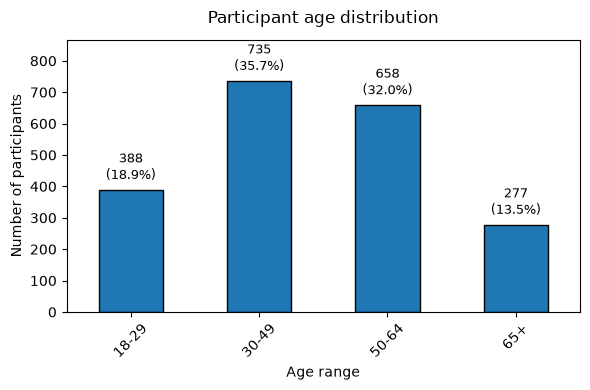

In [17]:
plot_categorical_distribution(
    demographics_df,
    "age_range",
    title="Participant age distribution",
    xlabel="Age range",
    category_order=[
        "18-29",
        "30-49",
        "50-64",
        "65+",
    ],
    figsize=(6, 4),
    rotation=45,
    max_label_length=20,
)

<Axes: title={'center': 'Participant race distribution'}, xlabel='Race', ylabel='Number of participants'>

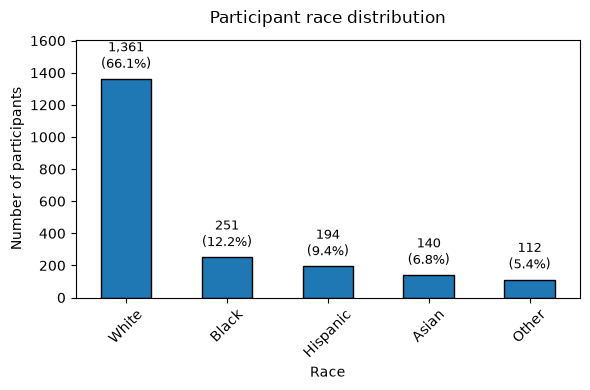

In [18]:
plot_categorical_distribution(
    demographics_df,
    "race_or_origin",
    title="Participant race distribution",
    xlabel="Race",
    figsize=(6, 4),
    rotation=45,
    max_label_length=20,
)

<Axes: title={'center': 'Participant education distribution'}, xlabel='Education', ylabel='Number of participants'>

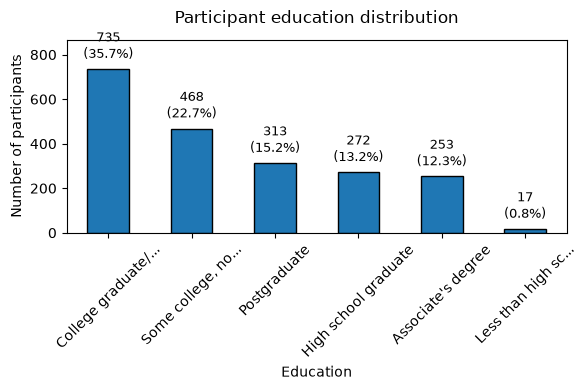

In [19]:
plot_categorical_distribution(
    demographics_df,
    "education",
    title="Participant education distribution",
    xlabel="Education",
    figsize=(6, 4),
    rotation=45,
    max_label_length=20,
)

<Axes: title={'center': 'Participant family income distribution'}, xlabel='Family Income', ylabel='Number of participants'>

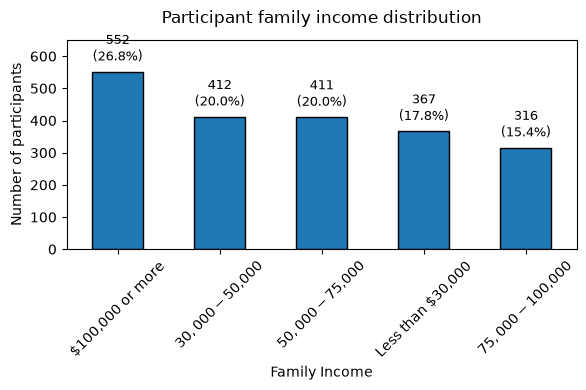

In [20]:
plot_categorical_distribution(
    demographics_df,
    "family_income",
    title="Participant family income distribution",
    xlabel="Family Income",
    figsize=(6, 4),
    rotation=45,
    max_label_length=20,
)

## Question Structure and Coverage
This section examines the question formats, how participant responses are encoded, and how consistently question IDs appear across participants.

### Question Catalog and Response Formats

In [21]:
catalog_path = hf_hub_download(
    repo_id=DATASET_ID,
    repo_type="dataset",
    filename=("question_catalog_and_human_response_csv/" "question_catalog.json"),
)
with open(catalog_path, encoding="utf-8") as file:
    question_catalog = json.load(file)

catalog_df = pd.DataFrame(question_catalog)

print(f"Participants: {wave_split.num_rows:,}")
print(f"Catalog records: {len(catalog_df):,}")

Participants: 2,058
Catalog records: 256


<Axes: title={'center': 'Question formats in the catalog'}, xlabel='Question type', ylabel='Catalog records'>

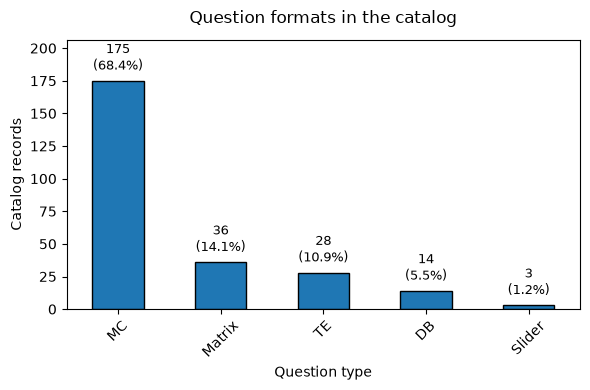

In [22]:
plot_categorical_distribution(
    catalog_df,
    "QuestionType",
    title="Question formats in the catalog",
    xlabel="Question type",
    ylabel="Catalog records",
    figsize=(6, 4),
    rotation=45,
)

### Examples of Questions and Response Formats

The dataset uses 5 questions formats: MC, Matrix, Slider, TE, DB. The examples below should how each format represents its prompts, response choices, and participant's answers.

In [23]:
QUESTION_TYPES = [
    "MC",
    "Matrix",
    "Slider",
    "TE",
    "DB",
]


def truncate_value(
    value: object,
    *,
    max_items: int = 3,
) -> object:
    """Shorten long lists for notebook display."""

    if not isinstance(value, list):
        return value

    if len(value) <= max_items:
        return value

    return [
        *value[:max_items],
        f"... ({len(value) - max_items} more)",
    ]


def question_example(
    question: dict,
) -> dict:
    """Select the fields needed to illustrate a question schema."""

    answers = question.get("Answers") or {}

    example = {
        "QuestionID": question.get("QuestionID"),
        "QuestionType": question.get("QuestionType"),
        "QuestionText": question.get("QuestionText"),
    }

    for field in [
        "Options",
        "Rows",
        "Statements",
    ]:
        value = question.get(field)

        if value:
            example[field] = truncate_value(value)

    if answers:
        example["Answers"] = {
            key: truncate_value(value) for key, value in answers.items()
        }

    return example

In [24]:
for question_type in QUESTION_TYPES:
    candidates = catalog_df.loc[catalog_df["QuestionType"].eq(question_type)]

    if candidates.empty:
        print(f"No {question_type} example found.")
        continue

    example_question = candidates.iloc[0].dropna().to_dict()

    print("=" * 80)
    print(f"Question type: {question_type}")
    print("=" * 80)

    print(
        json.dumps(
            question_example(example_question),
            indent=2,
            ensure_ascii=False,
            default=str,
        )
    )

Question type: MC
{
  "QuestionID": "QID11",
  "QuestionType": "MC",
  "QuestionText": "Which part of the United States do you currently live in?",
  "Options": [
    "Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)",
    "Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, MI, IN, OH)",
    "South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, MD, DE, VA, NC, SC, GA, FL)",
    "... (2 more)"
  ]
}
Question type: Matrix
{
  "QuestionID": "QID25",
  "QuestionType": "Matrix",
  "QuestionText": "Here are a number of characteristics that may or may not apply to you. Please indicate next to each statement the extent to which you agree or disagree with that statement. I see myself as someone who...",
  "Rows": [
    "Is talkative",
    "Tends to find fault with others",
    "Does a thorough job",
    "... (41 more)"
  ]
}
Question type: Slider
{
  "QuestionID": "QID154",
  "QuestionType": "Slider",
  "QuestionText": "A panel of psychologist have interviewed and administered personality tests to 30 enginee

### Persona Questions

<Axes: title={'center': 'Question formats in Waves 1-3 personas'}, xlabel='Question type', ylabel='Question records'>

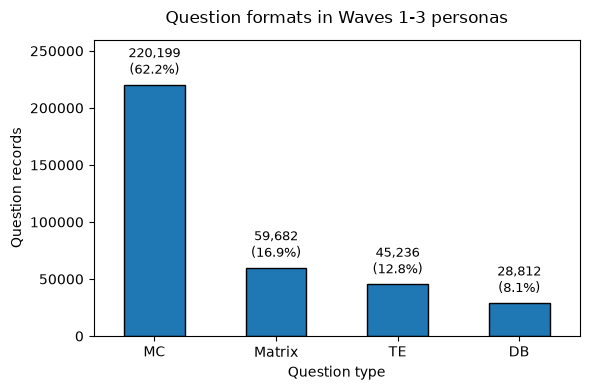

In [25]:
plot_categorical_distribution(
    persona_ques_df,
    "question_type",
    title="Question formats in Waves 1-3 personas",
    xlabel="Question type",
    ylabel="Question records",
    figsize=(6, 4),
    rotation=0,
)

### Participant Coverage by Question ID 

This subsection measures how many participants encountered each combination of block name and question ID in their waves 1-3 persona.

For most items, this combinations refers to the same question across participants. In randomized tasks such as pricing, the same question ID may correspond to similar questions with different products or prices. Therefore, question ID is used to describe a specific question scenario and not identical question wording.

In [26]:
question_id_coverage = persona_ques_df.groupby(
    [
        "block_name",
        "question_id",
    ],
    as_index=False,
    dropna=False,
).agg(
    participants=("pid", "nunique"),
    question_type=("question_type", "first"),
)

question_id_coverage["coverage_pct"] = (
    100 * question_id_coverage["participants"] / wave_split.num_rows
)

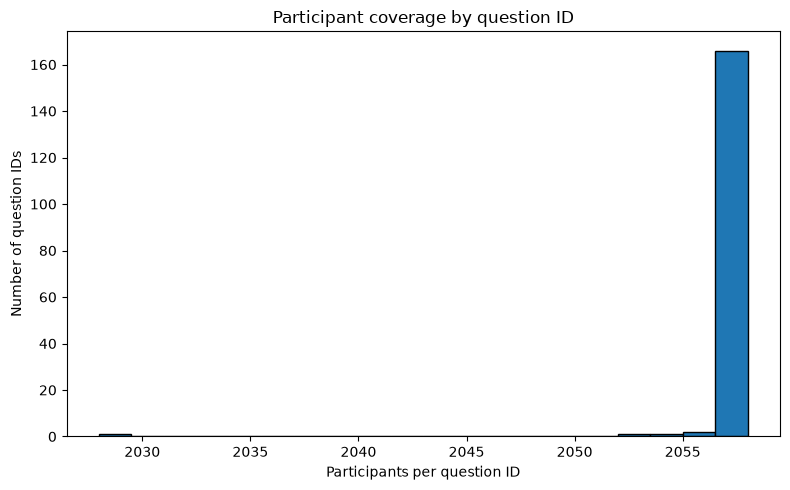

In [27]:
ax = question_id_coverage["participants"].plot.hist(
    bins=20,
    edgecolor="black",
    figsize=(8, 5),
)

ax.set_xlabel("Participants per question ID")
ax.set_ylabel("Number of question IDs")
ax.set_title("Participant coverage by question ID")

plt.tight_layout()
plt.show()

#### Finding
Question ID coverage is highly consistent across participants. Most persona question IDs appear for nearly all 2,058 participants. This indicates that differences between persons are based on their responses, rather than large differences in which questions they encountered. 

However, it is worth mentioning that coverage is calculated using block name and question ID and does not necessarily indicate identical wording. In randomized tasks, the same identifier may correspond to different experimental details across participants.

### Held out Evaluation Questions

`wave4_Q_wave4_A` contains questions and responses that serve as the prediction targets in the current modeling experiment. In the current modeling experiments, these held-out responses serve as the prediction targets.

In [28]:
records = []

for row in wave_split:
    for block in json.loads(row["wave4_Q_wave4_A"]):
        for question in block.get("Questions", []):
            records.append(
                {
                    "pid": row["pid"],
                    "block_name": block.get("BlockName"),
                    "question_id": question.get("QuestionID"),
                    "question_type": question.get("QuestionType"),
                    "question_text": question.get("QuestionText"),
                }
            )

heldout_ques_df = pd.DataFrame(records)

<Axes: title={'center': 'Question formats in the held-out set'}, xlabel='Question type', ylabel='Question records'>

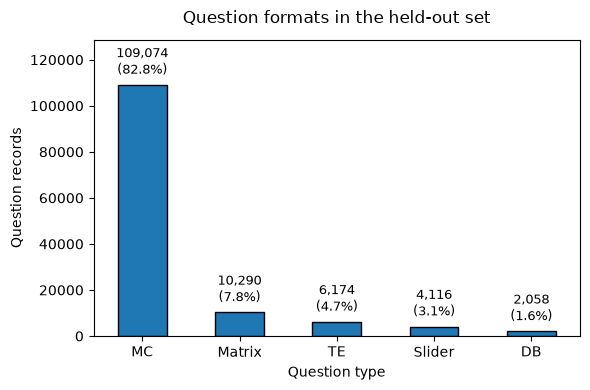

In [29]:
plot_categorical_distribution(
    heldout_ques_df,
    "question_type",
    title="Question formats in the held-out set",
    xlabel="Question type",
    ylabel="Question records",
    figsize=(6, 4),
    rotation=0,
)

<Axes: title={'center': 'Behavioral tasks represented in the held-out set'}, xlabel='Behavioral task', ylabel='Question records'>

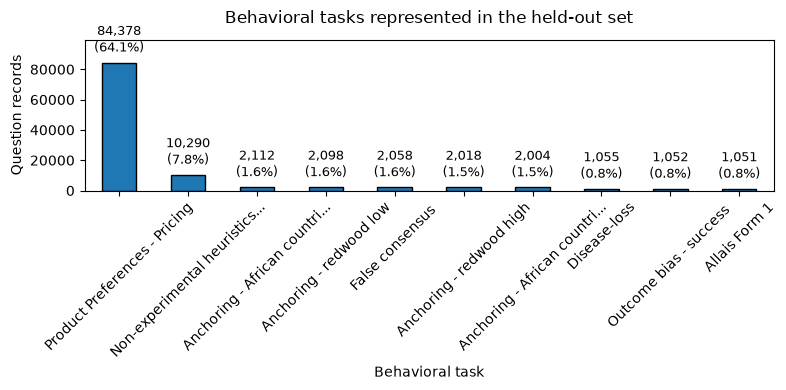

In [30]:
plot_categorical_distribution(
    heldout_ques_df,
    "block_name",
    title="Behavioral tasks represented in the held-out set",
    xlabel="Behavioral task",
    ylabel="Question records",
    top_n=10,
    figsize=(8, 4),
    rotation=45,
    max_label_length=30,
)

### Dynamic Pricing Questions

A `QuestionID` does not always uniquely identify an exact question.

For pricing tasks, `QuestionID` are used reused across participants while the randomized price in `QuestionText` may differ.

In [31]:
tmp_agg_df = (
    heldout_ques_df.groupby(["block_name", "question_id"])
    .agg({"question_text": lambda x: sorted(set(x))})
    .reset_index()
)

variable_question_ids = (
    tmp_agg_df.loc[tmp_agg_df["question_text"].str.len().gt(1)]
    .copy()
    .reset_index(drop=True)
)

In [32]:
variable_question_ids.iloc[3]

block_name                           Product Preferences - Pricing
question_id                                                QID9_12
question_text    [Please consider the following product categor...
Name: 3, dtype: object

## Load both dataset configurations

In [33]:
example = variable_question_ids.iloc[0]

print(
    f"Example identifier: {example['question_id']}\n"
    f"Unique texts: {len(example['question_text']):,}"
)

for text in example["question_text"][:3]:
    print(f"\n- {text}")

Example identifier: QID9_1
Unique texts: 437

- Please consider the following product category: Baby Milk and Milk Flavoring. Suppose you are in a grocery store, and you see the following product in that category: Horizon Organic Shelf-Stable Whole Milk Boxes, 8 oz., 12 Pack. The product is priced at: $0.00. Would you or would you not purchase this product?

- Please consider the following product category: Baby Milk and Milk Flavoring. Suppose you are in a grocery store, and you see the following product in that category: Horizon Organic Shelf-Stable Whole Milk Boxes, 8 oz., 12 Pack. The product is priced at: $11.18. Would you or would you not purchase this product?

- Please consider the following product category: Baby Milk and Milk Flavoring. Suppose you are in a grocery store, and you see the following product in that category: Horizon Organic Shelf-Stable Whole Milk Boxes, 8 oz., 12 Pack. The product is priced at: $13.98. Would you or would you not purchase this product?


## Summary

The dataset contains 2,058 US aults who completed all four waves. The dataset varies across age, sex assigned at birth, race, education and income. These attributes provide useful contextual information for persona construction.

Waves 1–3 personas contain cognitive tests, personality measures, economic preferences, and demographics. Question-slot coverage is highly consistent across participants. This suggests that persona differences primarily arise from participants' responses. However, randomized tasks demonstrate that the same question identifier may correspond to different wording or experimental values.

The dataset contains five response formats: multiple choice, matrix, slider, text entry, and descriptive blocks. Matrix questions may contain multiple atomic responses, so question counts are not equivalent to scored-response counts.
